In [209]:
from utils.random_forest_utils.rf_preprocessing_utils import WindowAlgPreprocessor

rf_preprocessor = WindowAlgPreprocessor(sensors_path="../../../../data/ml/features.csv", target_path="../../../../data/ml/targets.csv")
sensors_df, target_df = rf_preprocessor.read_data()
sensors_df = rf_preprocessor.feature_selection()
rf_preprocessor.normalize_angle()
sensors_df

,Experiment_ID,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm]
Time_[s],,,,,,,,,,,,,,,,,
0.00,2,0.135068,0.817045,0.293651,0.436154,0.397692,0.107143,0.985937,0.757580,0.59375,0.999967,1.000000,0.570124,0.000005,0.900879,0.000373,0.999849
0.05,2,0.135068,0.817045,0.285714,0.436154,0.397822,0.107143,0.985937,0.750271,0.59375,0.999967,1.000000,0.570124,0.000004,0.900879,0.000373,0.999842
0.10,2,0.135068,0.817045,0.293651,0.436154,0.398065,0.107143,0.984375,0.698300,0.59375,0.999967,1.000000,0.570124,0.000004,0.900879,0.000373,0.999540
0.15,2,0.136307,0.817045,0.293651,0.436154,0.397887,0.107143,0.985937,0.585460,0.62500,0.999967,1.000000,0.570124,0.000005,0.900879,0.000373,0.998401
0.20,2,0.135068,0.817045,0.285714,0.436154,0.397741,0.107143,0.984375,0.476972,0.65625,0.999967,1.000000,0.570124,0.000002,0.900879,0.000373,0.997003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86.30,314,0.074349,0.875032,0.285714,0.419720,0.414831,0.785714,0.926562,0.793701,0.43750,0.000007,0.997979,0.000004,0.984199,0.094463,0.000373,0.999849
86.35,314,0.074349,0.872084,0.293651,0.419720,0.415124,0.785714,0.928125,0.793552,0.43750,0.000007,0.998670,0.000004,0.984199,0.094463,0.000373,0.999849
86.40,314,0.074349,0.874473,0.285714,0.419720,0.415188,0.785714,0.926562,0.793404,0.43750,0.000007,0.999223,0.000004,0.984199,0.094463,0.000373,0.999849


In [210]:
import pandas as pd
import numpy as np

# Assume your DataFrame is called df and 'Time_[s]' is the index
df = sensors_df.reset_index()  # make 'Time_[s]' a column if it's the index

def resample_experiment(group, n=46):
    # Create 46 equally spaced timestamps between min and max time
    new_times = np.linspace(group['Time_[s]'].min(), group['Time_[s]'].max(), n)
    
    # Interpolate all columns (except 'Experiment_ID') to the new timestamps
    interpolated = pd.DataFrame({'Time_[s]': new_times})
    for col in group.columns:
        if col != 'Time_[s]' and col != 'Experiment_ID':
            interpolated[col] = np.interp(new_times, group['Time_[s]'], group[col])
    
    # Keep the Experiment_ID
    interpolated['Experiment_ID'] = group['Experiment_ID'].iloc[0]
    
    return interpolated

# Apply to each Experiment_ID
df_resampled = df.groupby('Experiment_ID').apply(lambda g: resample_experiment(g, n=46))
df_resampled = df_resampled.reset_index(drop=True)


In [211]:
import pandas as pd
import numpy as np

def normalize_experiment(group, n=46):
    if len(group) > n:
        # Just take the first 46 rows
        return group.iloc[:n].copy()
    else:
        # Already 46 rows
        return group.copy()

# Apply to each experiment
df_normalized = target_df.groupby('Experiment_ID', group_keys=False).apply(normalize_experiment, n=47)
df_normalized = df_normalized.reset_index(drop=True)


In [212]:
X = rf_preprocessor.group_and_pad(df_resampled, group_col="Experiment_ID")[:,:,1:]
Y = rf_preprocessor.group_and_pad(df_normalized, group_col="Experiment_ID")[:,:-1,2:]
X.shape

(100, 46, 16)

In [213]:
X_safe = X[0]
y_safe = Y[0]
X_safe.shape, y_safe.shape

((46, 16), (46, 3))

In [214]:
X.shape, Y.shape

((100, 46, 16), (100, 46, 3))

In [215]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import shap

# ---------------------------
# 1. Model fitting and evaluation
# ---------------------------
def fit_model(X, y, model_choice="random_forest"):
    # Only multi-output safe models
    models = {
        "random_forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "gradient_boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "linear_regression": LinearRegression(),
        "ridge": Ridge(alpha=1.0),
        "lasso": Lasso(alpha=0.1),
        "elasticnet": ElasticNet(alpha=0.1, l1_ratio=0.5),
        "mlp": MLPRegressor(hidden_layer_sizes=(100,100,100), random_state=42, max_iter=3000)
    }

    if model_choice not in models:
        print(f"Model {model_choice} not found. Using random_forest instead.")
        model_choice = "random_forest"

    model = models[model_choice]
    n_exp, n_timesteps, n_features = X.shape
    n_exp, n_timesteps, n_targets = y.shape
    X = X.reshape(n_exp * n_timesteps, n_features)  # shape: (100*46, 16)
    y = y.reshape(n_exp * n_timesteps, n_targets)
    # Ensure y is 2D
    y = np.asarray(y)
    if y.ndim == 1:
        y = y.reshape(-1, 1)

    # Fit model
    model.fit(X, y)

    # Predictions
    y_pred = model.predict(X)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    # Evaluate
    mae = mean_absolute_error(y, y_pred, multioutput="raw_values")
    r2 = r2_score(y, y_pred, multioutput="raw_values")
    
    for i, (mae_i, r2_i) in enumerate(zip(mae, r2)):
        print(f"Target {i+1}: MAE={mae_i:.4f}, R²={r2_i:.4f}")

    return model, y_pred

# ---------------------------
# 2. Compute feature window importance
# ---------------------------
def compute_feature_window_importance(X, y, model, window_size=20, stride=1, method_num=1):
    n_timesteps, n_features = X.shape
    n_feature_windows = (n_timesteps - window_size) // stride + 1
    feature_window_importance = []

    if method_num== 1:  # permutation importance
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break

                X_perm = X.copy()
                for f in range(n_features):
                    X_perm[start:end, f] = np.random.permutation(X_perm[start:end, f])

                y_hat = model.predict(X_perm)
                imp = np.mean(np.abs(y - y_hat))
                feature_window_importance.append(imp)

    elif method_num== 2:  # mean decrease impurity (only for tree-based models)
            if hasattr(model, "feature_importances_"):
                mdi_importance = model.feature_importances_
                baseline_error = mean_absolute_error(y, model.predict(X))

                for w in range(n_feature_windows):
                    start = w * stride
                    end = start + window_size
                    if end > n_timesteps:
                        break

                    y_window = y[start:end]
                    y_pred_window = model.predict(X[start:end, :])
                    window_error = mean_absolute_error(y_window, y_pred_window)
                    window_importance = np.sum(mdi_importance) * (window_error / baseline_error)
                    feature_window_importance.append(window_importance)
            else:
                raise ValueError("MDI method requires a tree-based model with feature_importances_")
            
    elif method_num== 3:  # SHAP importance
            # Compute SHAP values
            explainer = shap.Explainer(model.predict, X)
            shap_values = explainer(X)
            
            # Calculate window importance as mean absolute SHAP values per window
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break
                
                # Get SHAP values for this window and average across features and time
                window_shap = np.abs(shap_values.values[start:end, :])
                window_importance = np.mean(window_shap)
                feature_window_importance.append(window_importance)
                
    elif method_num== 4:  # leave-one-window-out importance
            baseline_pred = model.predict(X)
            baseline_error = np.mean(np.abs(y - baseline_pred))
            
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break

                # Mask window with mean values
                X_masked = X.copy()
                window_means = np.mean(X[start:end, :], axis=0)
                X_masked[start:end, :] = window_means
                
                y_hat_masked = model.predict(X_masked)
                masked_error = np.mean(np.abs(y - y_hat_masked))
                imp = masked_error - baseline_error
                feature_window_importance.append(imp)
                
    elif method_num== 5:  # zero-out window importance
            baseline_pred = model.predict(X)
            baseline_error = np.mean(np.abs(y - baseline_pred))
            
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break

                X_zero = X.copy()
                X_zero[start:end, :] = 0
                
                y_hat_zero = model.predict(X_zero)
                zero_error = np.mean(np.abs(y - y_hat_zero))
                imp = zero_error - baseline_error
                feature_window_importance.append(imp)

    elif method_num== 6:  # noise injection importance
            baseline_pred = model.predict(X)
            baseline_error = np.mean(np.abs(y - baseline_pred))
            
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break

                X_noise = X.copy()
                noise = np.random.normal(0, 0.1, X_noise[start:end, :].shape)
                X_noise[start:end, :] += noise
                
                y_hat_noise = model.predict(X_noise)
                noise_error = np.mean(np.abs(y - y_hat_noise))
                imp = noise_error - baseline_error
                feature_window_importance.append(imp)

    elif method_num== 7:  # feature drop importance
            baseline_pred = model.predict(X)
            baseline_error = np.mean(np.abs(y - baseline_pred))
            
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break

                X_drop = X.copy()
                X_drop[start:end, :] = np.mean(X_drop[start:end, :])
                
                y_hat_drop = model.predict(X_drop)
                drop_error = np.mean(np.abs(y - y_hat_drop))
                imp = drop_error - baseline_error
                feature_window_importance.append(imp)

    elif method_num== 8:  # partial dependence importance
            baseline_pred = model.predict(X)
            
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break

                X_pd = X.copy()
                # Use random values from other parts of the data
                random_indices = np.random.choice(n_timesteps, end-start)
                X_pd[start:end, :] = X[random_indices, :]
                
                y_hat_pd = model.predict(X_pd)
                pd_change = np.mean(np.abs(baseline_pred - y_hat_pd))
                feature_window_importance.append(pd_change)

    elif method_num== 9:  # variance-based importance
            baseline_pred = model.predict(X)
            
            for w in range(n_feature_windows):
                start = w * stride
                end = start + window_size
                if end > n_timesteps:
                    break

                X_var = X.copy()
                # Scale the window to increase variance
                X_var[start:end, :] = X_var[start:end, :] * 2
                
                y_hat_var = model.predict(X_var)
                var_change = np.mean(np.abs(baseline_pred - y_hat_var))
                feature_window_importance.append(var_change)

    total_importance = np.sum(feature_window_importance)
    importance_percentages = (np.array(feature_window_importance) / total_importance) * 100
    return feature_window_importance, importance_percentages, n_feature_windows
            

# ---------------------------
# 3. Plotting
# ---------------------------
def plot_feature_windows(X, y, feature_window_importance, importance_percentages,
                         window_size=20, stride=1, num_top_windows=2, target_window_idx=0):
    
    n_timesteps, n_features = X.shape
    top_window_indices = np.argsort(feature_window_importance)[-num_top_windows:][::-1]
    target_start = target_window_idx * stride
    target_end = target_start + window_size
    timesteps = np.arange(n_timesteps)
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    colors = plt.cm.tab10(np.linspace(0, 1, n_features))
    
    # Plot features
    for f in range(n_features):
        axes[0].plot(timesteps, X[:, f], marker='.', markersize=5, color=colors[f],
                     linestyle='-', alpha=0.6, label=f'Feature {f+1}')
    
    # Highlight top windows
    highlight_colors = ['red', 'orange', 'purple', 'green', 'brown', 'cyan', 'magenta', 'yellow']
    for i, window_idx in enumerate(top_window_indices):
        if i < len(highlight_colors):
            start = window_idx * stride
            end = start + window_size
            axes[0].axvspan(start, end, color=highlight_colors[i], alpha=0.4,
                            label=f'Top {i+1} ({importance_percentages[window_idx]:.1f}%)')
            mid = (start + end) / 2
            y_range = axes[0].get_ylim()
            text_y = y_range[1] - 0.05 * (y_range[1] - y_range[0]) * (i+1)
            axes[0].text(mid, text_y, f'{importance_percentages[window_idx]:.1f}%',
                         ha='center', va='center', fontweight='bold',
                         bbox=dict(boxstyle="round,pad=0.3", facecolor=highlight_colors[i], alpha=0.8))
    
    axes[0].set_ylabel("Feature values")
    axes[0].set_title("Feature values with top important windows highlighted")
    axes[0].grid(True, alpha=0.3)
    
    # Plot target
    if y.ndim == 1:
        axes[1].plot(timesteps, y, marker='.', markersize=2, color='blue', linestyle='-', alpha=0.8, linewidth=0.5)
    else:
        for i in range(y.shape[1]):
            axes[1].plot(timesteps, y[:, i], marker='.', markersize=2, linestyle='-', alpha=0.8, label=f'Target {i+1}')
    
    axes[1].axvspan(target_start, target_end, color='grey', alpha=0.4, label='Selected target window')
    axes[1].set_xlabel("Time steps")
    axes[1].set_ylabel("Target")
    axes[1].set_title("Target values with selected window highlighted")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# ---------------------------
# 4. Additional analysis plotting
# ---------------------------
def plot_importance_analysis(feature_window_importance, importance_percentages, num_top_windows=2):
    n_feature_windows = len(feature_window_importance)
    top_window_indices = np.argsort(feature_window_importance)[-num_top_windows:][::-1]
    highlight_colors = ['red', 'orange', 'purple', 'green', 'brown', 'cyan', 'magenta', 'yellow']

    plt.figure(figsize=(14, 8))
    
    # Importance scores
    plt.subplot(2, 2, 1)
    bars = plt.bar(range(n_feature_windows), feature_window_importance, color='skyblue', alpha=0.7)
    for i, window_idx in enumerate(top_window_indices):
        if i < len(highlight_colors):
            bars[window_idx].set_color(highlight_colors[i])
            bars[window_idx].set_alpha(0.8)
    plt.xlabel('Window Number')
    plt.ylabel('Importance Score')
    plt.title('Feature Window Importance Scores')
    plt.xticks(range(n_feature_windows))
    plt.grid(axis='y', alpha=0.3)
    


Target 1: MAE=0.0128, R²=0.9601
Target 2: MAE=0.0159, R²=0.9596
Target 3: MAE=0.0127, R²=0.9606


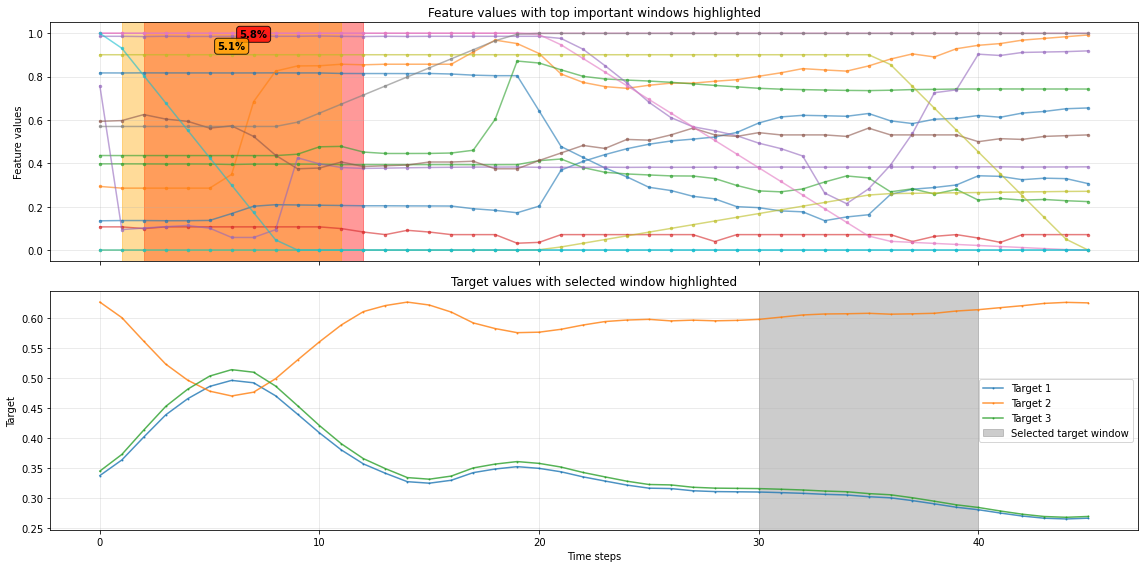

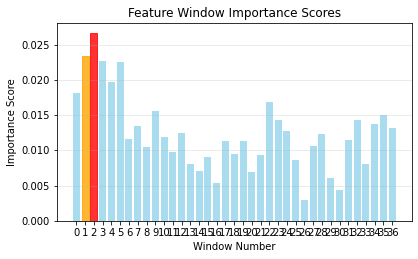

In [216]:
# ---------------------------
# Configurations
# ---------------------------
# "random_forest- 0
# "linear_regression- 2
# "ridge"- 3
# "mlp"- 6
window_size = 10
stride = 1
method_num = 8          # 1 = permutation importance, 2 = MDI (only tree-based)
num_top_windows = 2
target_window_idx = 30
model_choice = 'random_forest'

model, y_pred = fit_model(X, Y, model_choice=model_choice)
feature_window_importance, importance_percentages, n_feature_windows = compute_feature_window_importance(
    X_safe, y_safe, model,
    window_size=window_size,
    stride=stride,
    method_num=method_num
)
plot_feature_windows(
    X_safe, y_safe,
    feature_window_importance, importance_percentages,
    window_size=window_size,
    stride=stride,
    num_top_windows=num_top_windows,
    target_window_idx=target_window_idx
)
plot_importance_analysis(feature_window_importance, importance_percentages, num_top_windows=num_top_windows)


# LIFT

In [224]:
import torch
import torch.nn as nn
import torch.optim as optim
from captum.attr import DeepLift
import numpy as np
import matplotlib.pyplot as plt

x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(Y, dtype=torch.float32)

feature_names = list(sensors_df.columns)[1:]

# --------------------------
# More Complex LSTM Model
# --------------------------
class ComplexLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers, 
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.layer_norm = nn.LayerNorm(hidden_dim*2)
        self.fc1 = nn.Linear(hidden_dim*2, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        out, _ = self.lstm(x)                # (batch, seq_len, hidden_dim*2)
        out = self.layer_norm(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

model = ComplexLSTM(input_dim=16, hidden_dim=128, output_dim=3, num_layers=3)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)

# --------------------------
# Training loop
# --------------------------
epochs = 500
batch_size = 32

for epoch in range(epochs):
    permutation = torch.randperm(x_tensor.size(0))
    epoch_loss = 0
    
    for i in range(0, x_tensor.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = x_tensor[indices], y_tensor[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / (x_tensor.size(0)//batch_size)
    scheduler.step(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

print("Training complete!")


# --------------------------
# More Complex LSTM Model
# --------------------------
class ComplexLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers, 
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.layer_norm = nn.LayerNorm(hidden_dim*2)
        self.fc1 = nn.Linear(hidden_dim*2, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        out, _ = self.lstm(x)                # (batch, seq_len, hidden_dim*2)
        out = self.layer_norm(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

model = ComplexLSTM(input_dim=16, hidden_dim=128, output_dim=3, num_layers=3)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)

# --------------------------
# Training loop
# --------------------------
epochs = 500
batch_size = 32

for epoch in range(epochs):
    permutation = torch.randperm(x_tensor.size(0))
    epoch_loss = 0
    
    for i in range(0, x_tensor.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = x_tensor[indices], y_tensor[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / (x_tensor.size(0)//batch_size)
    scheduler.step(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

print("Training complete!")


Epoch 1/500, Loss: 0.132347
Epoch 2/500, Loss: 0.029381
Epoch 3/500, Loss: 0.024040
Epoch 4/500, Loss: 0.027514
Epoch 5/500, Loss: 0.020685
Epoch 6/500, Loss: 0.017357
Epoch 7/500, Loss: 0.021545
Epoch 8/500, Loss: 0.020835
Epoch 9/500, Loss: 0.017357
Epoch 10/500, Loss: 0.023647
Epoch 11/500, Loss: 0.021238
Epoch 12/500, Loss: 0.018678
Epoch 13/500, Loss: 0.020407
Epoch 14/500, Loss: 0.017559
Epoch 15/500, Loss: 0.021587
Epoch 16/500, Loss: 0.016206
Epoch 17/500, Loss: 0.020436


KeyboardInterrupt: 

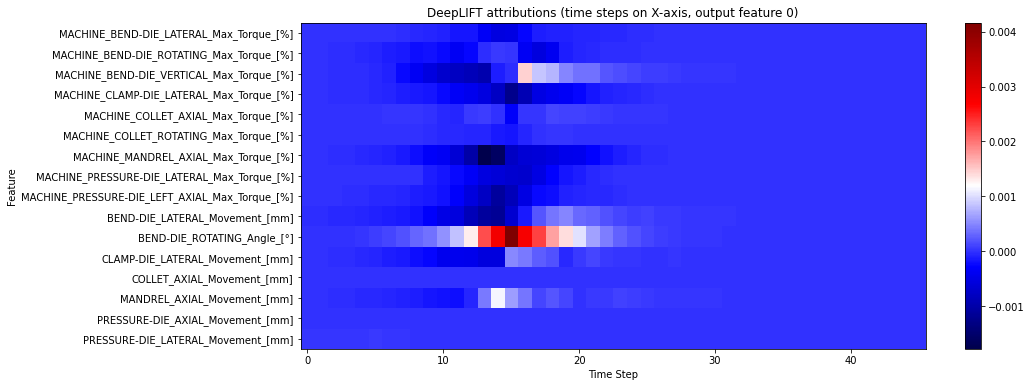

In [225]:
from captum.attr import DeepLift
feature_names = list(sensors_df.columns)[1:]
# --------------------------
# Pick a sample input to explain
# --------------------------
sample_input = x_tensor[0:1]  # (1,46,16)
target_time_step = 15
target_output_feature = 0

# --------------------------
# Wrap model for scalar output
# --------------------------
class WrappedModel(nn.Module):
    def __init__(self, base_model, time_step, output_feature):
        super().__init__()
        self.base_model = base_model
        self.time_step = time_step
        self.output_feature = output_feature
    def forward(self, x):
        out = self.base_model(x)
        return out[:, self.time_step, self.output_feature]  # scalar per batch

wrapped_model = WrappedModel(model, target_time_step, target_output_feature)

# --------------------------
# DeepLIFT attribution
# --------------------------
deeplift = DeepLift(wrapped_model)
attr = deeplift.attribute(sample_input)
attr_np = attr.detach().numpy().reshape(46,16)

# --------------------------
# Visualization
# --------------------------
plt.figure(figsize=(14,6))
plt.imshow(attr_np.T, cmap='seismic', aspect='auto')  # time on X-axis
plt.colorbar()
plt.title(f"DeepLIFT attributions (time steps on X-axis, output feature {target_output_feature})")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=np.arange(len(feature_names)), labels=feature_names)
plt.show()


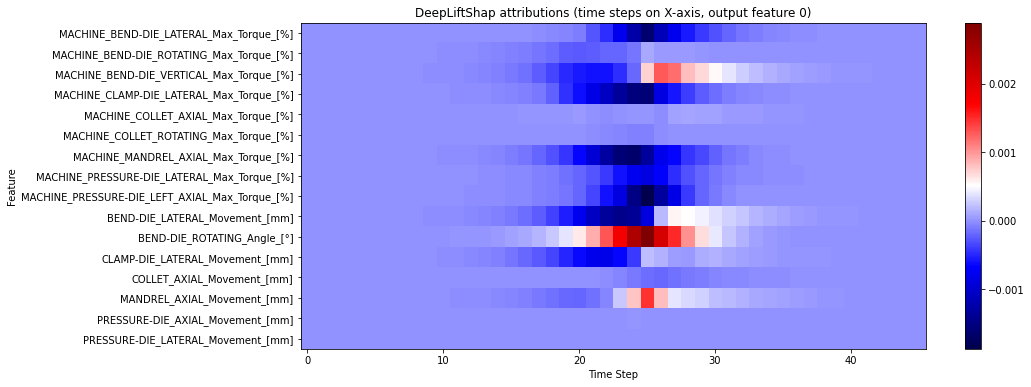

In [226]:
from captum.attr import DeepLiftShap
import matplotlib.pyplot as plt

# --------------------------
# Pick a sample input to explain
# --------------------------
sample_input = x_tensor[0:1]  # (1,46,16)
target_time_step = 25
target_output_feature = 0

# --------------------------
# Wrap model for scalar output
# --------------------------
class WrappedModel(nn.Module):
    def __init__(self, base_model, time_step, output_feature):
        super().__init__()
        self.base_model = base_model
        self.time_step = time_step
        self.output_feature = output_feature
    def forward(self, x):
        out = self.base_model(x)
        return out[:, self.time_step, self.output_feature]

wrapped_model = WrappedModel(model, target_time_step, target_output_feature)

# --------------------------
# For DeepLiftShap, use multiple baselines
# --------------------------
num_baselines = 10
baseline = torch.zeros((num_baselines, sample_input.size(1), sample_input.size(2)))
baseline += torch.rand_like(baseline) * 0.01  # optional small noise

# --------------------------
# DeepLiftShap attribution
# --------------------------
deeplift_shap = DeepLiftShap(wrapped_model)
attr = deeplift_shap.attribute(sample_input, baselines=baseline)
attr_np = attr.detach().numpy().reshape(46,16)

# --------------------------
# Visualization
# --------------------------
plt.figure(figsize=(14,6))
plt.imshow(attr_np.T, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title(f"DeepLiftShap attributions (time steps on X-axis, output feature {target_output_feature})")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=np.arange(len(feature_names)), labels=feature_names)
plt.show()


In [47]:
%%capture
!pip uninstall timesynth --yes
!pip install git+https://github.com/TimeSynth/TimeSynth.git

WinIT attributions shape: (1, 16, 46, 3)


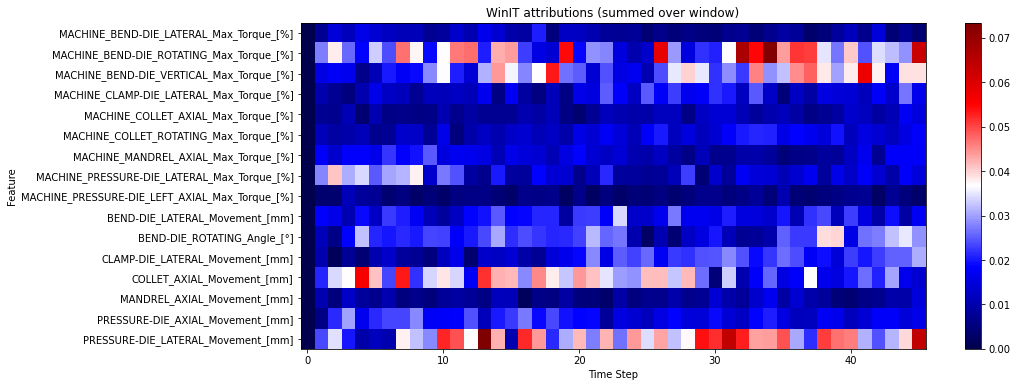

In [227]:
from __future__ import annotations

import logging
from pathlib import Path
from time import time

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# --------------------------
# Your LSTM model
# --------------------------
class LSTMTimeSeries(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        out, _ = self.lstm(x)  # out: (batch, seq_len, hidden_dim)
        out = self.fc(out)      # (batch, seq_len, output_dim)
        return out

# --------------------------
# Wrapper for WinIT
# --------------------------
class LSTMWrapper(nn.Module):
    """
    Wrap the LSTM model to provide .predict() for WinITExplainer.
    Handles (batch, features, time_steps) -> (batch, time_steps, features)
    """
    def __init__(self, model: nn.Module, device=torch.device("cpu")):
        super().__init__()
        self.model = model.to(device)
        self.device = device
        self.num_states = model.fc.out_features

    def forward(self, x):
        return self.predict(x)

    def predict(self, x: torch.Tensor, return_all=False):
        # Swap axes: (batch, features, time_steps) -> (batch, time_steps, features)
        x = x.permute(0, 2, 1).to(self.device)
        with torch.no_grad():
            out = self.model(x)  # (batch, time_steps, output_dim)
        if return_all:
            return out
        return out[:, -1, :]  # last time step

# --------------------------
# Prepare data loader
# --------------------------
batch_size = 16
dataset = TensorDataset(x_tensor, y_tensor)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# --------------------------
# Initialize WinITExplainer
# --------------------------
from winit.explainer.winitexplainers import WinITExplainer

device = torch.device("cpu")
num_features = x_tensor.shape[2]

lstm_model = LSTMTimeSeries(input_dim=num_features, hidden_dim=32, output_dim=y_tensor.shape[2])
wrapped_model = LSTMWrapper(lstm_model, device=device)

explainer = WinITExplainer(
    device=device,
    num_features=num_features,
    data_name="mydata",
    path=Path("./winit_generators"),
    train_loader=train_loader,
    window_size=3,
    num_samples=3,
    conditional=False,
    joint=False,
    metric="pd",
    random_state=42
)
explainer.base_model = wrapped_model

# --------------------------
# Pick a sample input and compute attributions
# --------------------------
sample_input = x_tensor[1:2]  # shape: (1, time_steps, features)
# WinIT expects shape: (batch, features, time_steps)
sample_input = sample_input.permute(0, 2, 1)

attributions = explainer.attribute(sample_input)
print("WinIT attributions shape:", attributions.shape)  # (1, features, time_steps, window_size)

# --------------------------
# Visualize attributions
# --------------------------
import matplotlib.pyplot as plt

# Sum over window dimension for visualization
attr_sum = attributions[0].sum(axis=-1)  # (features, time_steps)
plt.figure(figsize=(14,6))
plt.imshow(attr_sum, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title("WinIT attributions (summed over window)")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=np.arange(len(feature_names)), labels=feature_names)
plt.show()


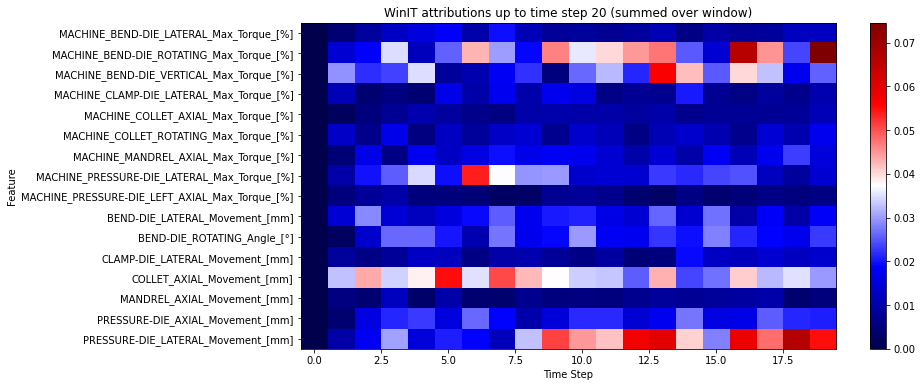

In [228]:
# Suppose your sample_input is already prepared: (batch, features, time_steps)
attributions = explainer.attribute(sample_input)  # shape: (1, features, time_steps, window_size)

# Specify the timestamp (time step index) you want to go up to
t_max = 20  # example: get attributions from t=0 to t=10

# Slice the attributions along the time_steps axis
attr_up_to_t = attributions[0, :, :t_max, :15]  # shape: (features, t_max, window_size)

# For visualization, you might sum over the window dimension
attr_sum_up_to_t = attr_up_to_t.sum(axis=-1)  # shape: (features, t_max)

import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.imshow(attr_sum_up_to_t, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title(f"WinIT attributions up to time step {t_max} (summed over window)")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=np.arange(len(feature_names)), labels=feature_names)
plt.show()


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/arman/.conda/envs/winit/lib/python3.8/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name  | Type    | Params | Mode 
------------------------------------------
0 | net   | Mask    | 73.6 K | train
1 | _loss | MSELoss | 0      | train
------------------------------------------
73.6 K    Trainable params
0         Non-trainable params
73.6 K    Total params
0.294     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode
/home/arman/.conda/envs/winit/lib/python3.8/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to impr

Epoch 0:   0%|          | 0/4 [00:00<?, ?it/s] 

Epoch 99: 100%|██████████| 4/4 [00:00<00:00, 31.03it/s, v_num=12]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 4/4 [00:00<00:00, 27.48it/s, v_num=12]


/home/arman/.conda/envs/winit/lib/python3.8/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 4/4 [00:00<00:00, 57.78it/s]


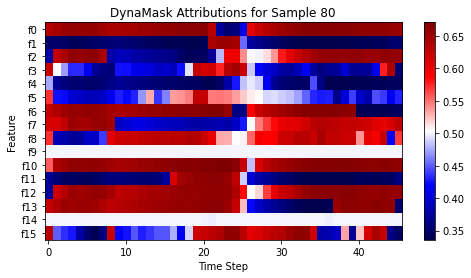

In [230]:
import torch as th
import matplotlib.pyplot as plt
from tint.attr import DynaMask
from tint.models import MLP

# --------------------------tint library
# Dummy data
# --------------------------
inputs = th.from_numpy(X).float() 
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, 
                          num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, features)
        out, _ = self.rnn(x)  # out: (batch, seq_len, hidden_size)
        out = self.fc(out)    # shape: (batch, seq_len, output_size)
        # if you want only the last time step prediction:
        # out = out[:, -1, :]
        return out

rnn = SimpleRNN(input_size=X.shape[-1], hidden_size=15, num_layers=1, output_size=1)

# --------------------------
# Compute attributions
# --------------------------
explainer = DynaMask(rnn)
attr = explainer.attribute(inputs)  # shape: (batch, time, features, ? depends on DynaMask)

# Convert to numpy for visualization
attr_np = attr.detach().numpy()

# --------------------------
# Visualization
# --------------------------
feature_names = [f"f{i}" for i in range(inputs.size(2))]

# Plot heatmap for each sample

plt.figure(figsize=(8,4))
plt.imshow(attr_np[0].T, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title(f"DynaMask Attributions for Sample {i}")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=range(len(feature_names)), labels=feature_names)
plt.show()


In [ ]:
import torch as th
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tint.attr import SequentialIntegratedGradients

# --------------------------
# Assume X and Y are your data
# X shape: [num_samples, time_steps, features]
# Y shape: [num_samples, time_steps, all_features]
# --------------------------

# Example: Use first 5 samples
inputs = th.tensor(X[:10,:,:]).float()
X_tensor = th.tensor(X[:10,:,:]).float()
# Select only the outputs you want to predict, one value per output per sample
y_tensor = th.tensor(Y[:10, :, 1]).float()  # last timestep, outputs 1 and 2
batch_size, time_steps, features = X_tensor.shape
num_outputs = y_tensor.shape[1]

# --------------------------
# Define LSTM Regressor
# --------------------------
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)  # map last hidden to multiple outputs

    def forward(self, x):
        out, _ = self.lstm(x)         # [batch, time_steps, hidden_size]
        out = out[:, -1, :]           # take last timestep
        out = self.fc(out)            # [batch, num_outputs]
        return out

hidden_size = 32
mlp = LSTMRegressor(features, hidden_size, num_outputs)

criterion = nn.MSELoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.001)

# --------------------------
# Train LSTM
# --------------------------
num_epochs = 100
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = mlp(X_tensor)          # [batch, num_outputs]
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [10/100], Loss: 0.3024
Epoch [20/100], Loss: 0.1793
Epoch [30/100], Loss: 0.0590
Epoch [40/100], Loss: 0.0175
Epoch [50/100], Loss: 0.0035
Epoch [60/100], Loss: 0.0017
Epoch [70/100], Loss: 0.0010
Epoch [80/100], Loss: 0.0006
Epoch [90/100], Loss: 0.0005
Epoch [100/100], Loss: 0.0004


In [ ]:
# --------------------------
# Compute Attributions
# --------------------------
explainer = SequentialIntegratedGradients(mlp)

# Compute attributions for each output separately
attrs = []
for target_idx in range(num_outputs):
    attr = explainer.attribute(inputs, target=target_idx)
    attrs.append(attr.detach().numpy())  # shape: [batch, time_steps, features]

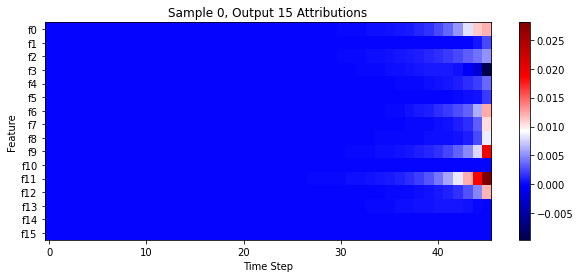

In [ ]:
# --------------------------
# Visualization
# --------------------------
feature_names = [f"f{i}" for i in range(features)]

plt.figure(figsize=(10,4))
plt.imshow(attrs[15][0].T, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title(f"Sample {0}, Output {15} Attributions")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=range(len(feature_names)), labels=feature_names)
plt.show()

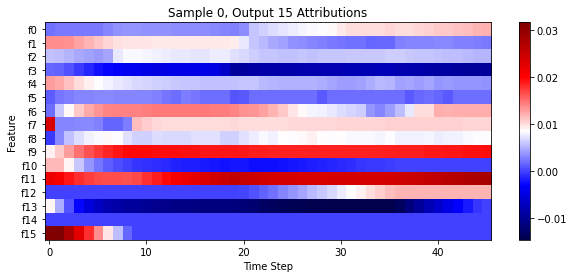

In [132]:
import torch as th
from tint.attr import TemporalIntegratedGradients
from tint.models import MLP

explainer = TemporalIntegratedGradients(mlp)
# --------------------------
# Visualization
# --------------------------
attrs = []
for target_idx in range(num_outputs):
    attr = explainer.attribute(inputs, target=target_idx)
    attrs.append(attr.detach().numpy())  # shape: [batch, time_steps, features]


# --------------------------
# Visualization
# --------------------------
feature_names = [f"f{i}" for i in range(features)]

plt.figure(figsize=(10,4))
plt.imshow(attrs[15][0].T, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title(f"Sample {0}, Output {15} Attributions")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=range(len(feature_names)), labels=feature_names)
plt.show()

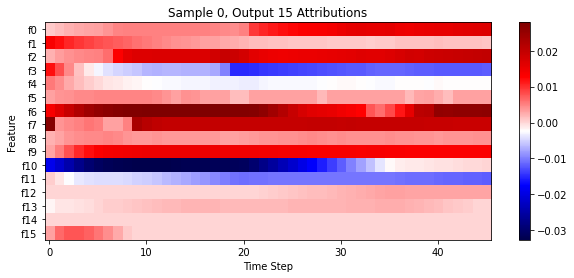

In [133]:
# --------------------------
# Visualization
# --------------------------
feature_names = [f"f{i}" for i in range(features)]

plt.figure(figsize=(10,4))
plt.imshow(attrs[45][0].T, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title(f"Sample {0}, Output {15} Attributions")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=range(len(feature_names)), labels=feature_names)
plt.show()

In [134]:
import torch as th
from tint.attr import TimeForwardTunnel
from captum.attr import Saliency
from tint.models import MLP

explainer = TimeForwardTunnel(Saliency(mlp))
# --------------------------
# Visualization
# --------------------------
attrs = []
for target_idx in range(num_outputs):
    attr = explainer.attribute(inputs, target=target_idx)
    attrs.append(attr.detach().numpy())  # shape: [batch, time_steps, features]


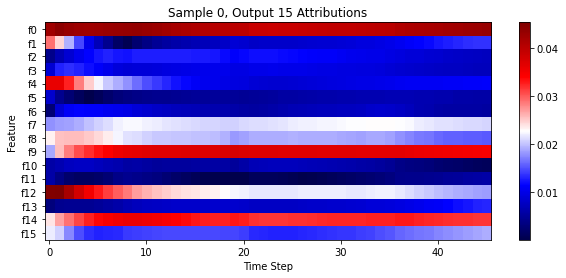

In [135]:
# --------------------------
# Visualization
# --------------------------
feature_names = [f"f{i}" for i in range(features)]

plt.figure(figsize=(10,4))
plt.imshow(attrs[0][0].T, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title(f"Sample {0}, Output {15} Attributions")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=range(len(feature_names)), labels=feature_names)
plt.show()